### Preparação e parâmetros

O deslocamento vibratório é medido em milímetros. A malha densa representa numericamente o modelo contínuo; não é uma medição contínua real. Todas as comparações utilizam o mesmo modelo e o mesmo intervalo de dois segundos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

A1, A2 = 1.0, 0.25  # mm
f1, f2 = 5.0, 15.0  # Hz
phi1, phi2 = 0.0, np.pi / 4  # rad
T = 2.0  # s
fs = 200.0  # Hz
Ts = 1 / fs
bits = [4, 8]
limite = 1.5  # faixa do conversor: -1.5 a +1.5 mm
sigma = 0.15  # desvio padrão do ruído, mm
M = 5
rng = np.random.default_rng(42)

def modelo(t):
    return A1 * np.cos(2 * np.pi * f1 * t + phi1) + A2 * np.cos(2 * np.pi * f2 * t + phi2)

t = np.linspace(0, T, 10001)
n = np.arange(int(T * fs))
tn = n * Ts
xc = modelo(t)
x = modelo(tn)

plt.rcParams.update({"font.size": 10, "figure.figsize": (11, 4)})
def configurar(ax, titulo, ylabel="Deslocamento (mm)", xlabel="Tempo (s)"):
    ax.set(title=titulo, xlabel=xlabel, ylabel=ylabel)
    ax.grid(True, alpha=0.3)

def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))


### Etapas 1 e 2 — Modelagem e geração

$$x(t)=1\cos(2\pi\cdot5t)+0{,}25\cos(2\pi\cdot15t+\pi/4)\quad[\mathrm{mm}].$$

A primeira parcela representa a oscilação principal da máquina, e a segunda, uma componente harmônica de menor amplitude. As fases fixam a posição de cada oscilação no início da observação. Trata-se de um modelo idealizado de vibração, sem dados experimentais.

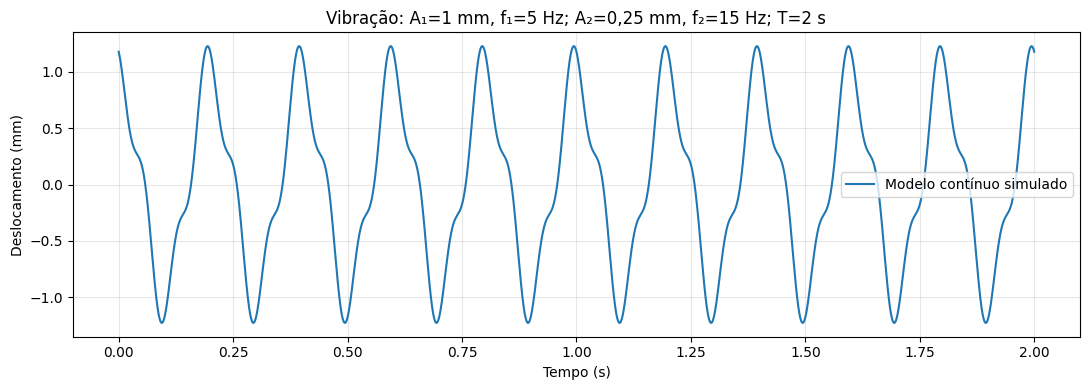

In [2]:
fig, ax = plt.subplots()
ax.plot(t, xc, label="Modelo contínuo simulado")
configurar(ax, "Vibração: A₁=1 mm, f₁=5 Hz; A₂=0,25 mm, f₂=15 Hz; T=2 s")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretação:** a oscilação principal tem período de 0,2 s. A componente de 15 Hz modifica a forma de cada ciclo. Como as frequências são múltiplos de 5 Hz, o sinal composto repete seu padrão a cada 0,2 s. O módulo é limitado por $A_1+A_2=1{,}25$ mm, cabendo na faixa do conversor.

### Etapa 3 — Amostragem

Para $f_s=200$ Hz, $T_s=0{,}005$ s e $x[n]=x(nT_s)$, com $n=0,\ldots,399$. A janela discreta é $0\leq t_n<2$ s. A maior frequência do modelo é 15 Hz, portanto $200>2\cdot15$ satisfaz a condição de Nyquist. Comparamos também $f_s=20$ Hz, que não atende essa condição.

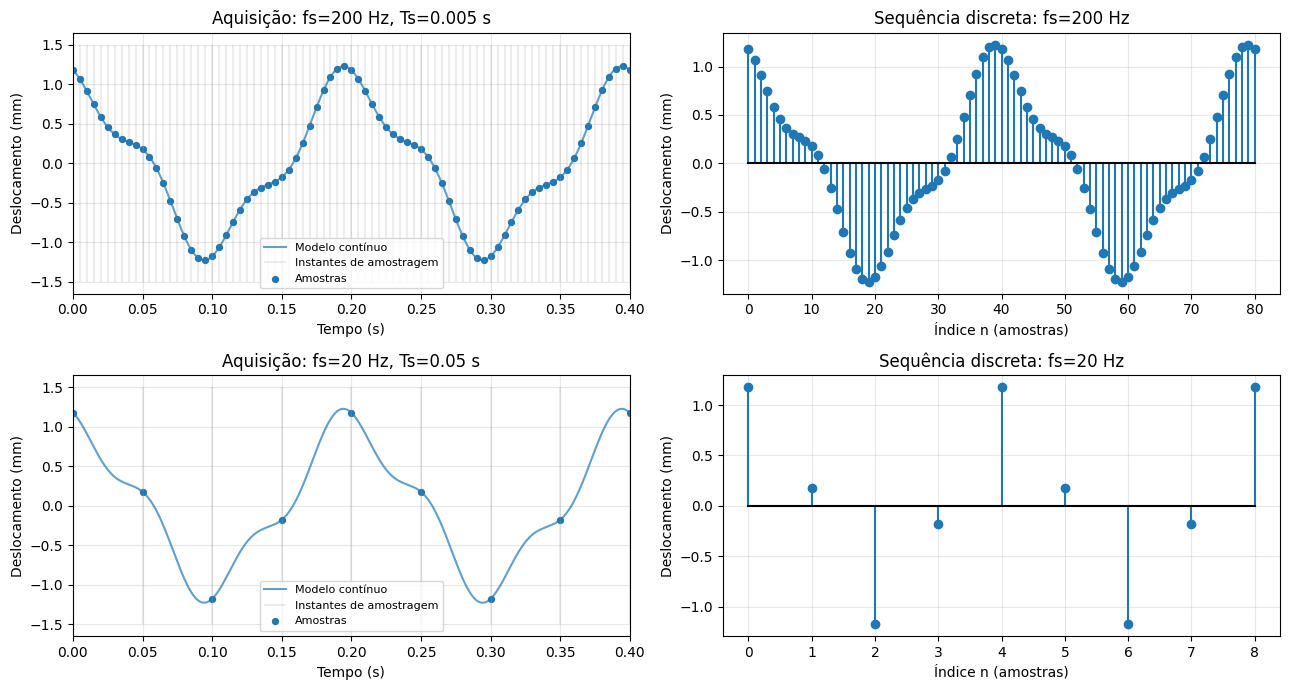

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for row, taxa in enumerate([fs, 20.0]):
    indices = np.arange(int(T * taxa))
    instantes = indices / taxa
    amostras = modelo(instantes)
    janela = instantes <= 0.4
    axes[row, 0].plot(t, xc, label="Modelo contínuo", alpha=0.7)
    axes[row, 0].vlines(instantes[janela], -1.5, 1.5, color="gray", alpha=0.15, label="Instantes de amostragem")
    axes[row, 0].scatter(instantes, amostras, s=18, label="Amostras")
    axes[row, 0].set_xlim(0, 0.4)
    configurar(axes[row, 0], f"Aquisição: fs={taxa:g} Hz, Ts={1/taxa:g} s")
    axes[row, 1].stem(indices[janela], amostras[janela], basefmt="k-")
    configurar(axes[row, 1], f"Sequência discreta: fs={taxa:g} Hz", xlabel="Índice n (amostras)")
    axes[row, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()

**Interpretação:** a 200 Hz há 40 amostras por ciclo da componente principal e aproximadamente 13,33 por ciclo da componente de 15 Hz. A 20 Hz, a componente de 15 Hz aparece como uma componente de 5 Hz, pois $15=20-5$; sua fase se inverte na representação equivalente. Ela se mistura à componente principal, impedindo distinguir as duas frequências pelas amostras. Aumentar a taxa melhora a representação, mas não elimina ruído nem erro de quantização.

### Etapa 4 — Quantização

Adotamos um quantizador uniforme com $L=2^N$ níveis incluindo os extremos $-V$ e $V$, onde $V=1{,}5$ mm. Nesta convenção,

$$\Delta_N=\frac{2V}{2^N-1},\qquad q_N[n]=-V+\Delta_N\operatorname{round}\left(\frac{\operatorname{clip}(x[n],-V,V)+V}{\Delta_N}\right).$$

Não há saturação do sinal ideal, pois $|x[n]|\leq1{,}25<V$. Essa convenção usa espaçamento $2V/(2^N-1)$; um conversor com outra definição de níveis pode usar $2V/2^N$.

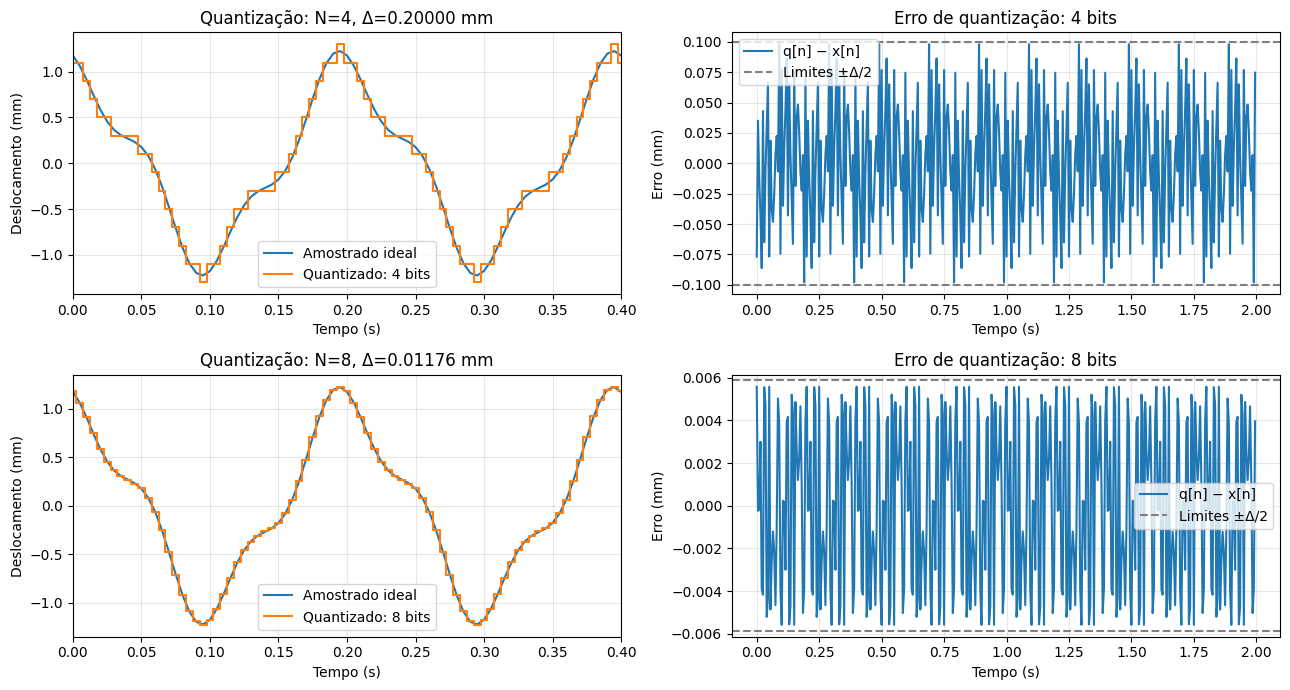

,Bits,Níveis,Passo (mm),RMSE (mm),Erro máximo (mm)
0,4,16,0.200000,0.052202,0.097979
1,8,256,0.011765,0.003985,0.005576


In [4]:
def quantizar(valores, N):
    passo = 2 * limite / (2 ** N - 1)
    limitado = np.clip(valores, -limite, limite)
    indices = np.rint((limitado + limite) / passo)
    return -limite + passo * indices, passo

quantizados = {}
linhas = []
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for row, N in enumerate(bits):
    q, passo = quantizar(x, N)
    quantizados[N] = q
    erro = q - x
    linhas.append({"Bits": N, "Níveis": 2 ** N, "Passo (mm)": passo,
                   "RMSE (mm)": rmse(q, x), "Erro máximo (mm)": np.max(np.abs(erro))})
    axes[row, 0].plot(tn, x, label="Amostrado ideal")
    axes[row, 0].step(tn, q, where="mid", label=f"Quantizado: {N} bits")
    axes[row, 0].set_xlim(0, 0.4)
    configurar(axes[row, 0], f"Quantização: N={N}, Δ={passo:.5f} mm")
    axes[row, 0].legend()
    axes[row, 1].plot(tn, erro, label="q[n] − x[n]")
    axes[row, 1].axhline(passo / 2, color="gray", linestyle="--", label="Limites ±Δ/2")
    axes[row, 1].axhline(-passo / 2, color="gray", linestyle="--")
    configurar(axes[row, 1], f"Erro de quantização: {N} bits", ylabel="Erro (mm)")
    axes[row, 1].legend()
plt.tight_layout()
plt.show()
display(pd.DataFrame(linhas).round(6))


**Interpretação:** com 4 bits existem 16 níveis e $\Delta_4=0{,}2$ mm; com 8 bits existem 256 níveis e $\Delta_8\approx0{,}011765$ mm. O segundo caso acompanha melhor as amostras e reduz o erro. Como não há saturação, o erro absoluto fica limitado a meio passo. As linhas entre amostras auxiliam a leitura; não representam uma reconstrução física do sinal.

### Etapa 5 — Inclusão de ruído

O ramo de processamento utiliza a resolução de 8 bits:

$$x_r[n]=q_8[n]+r[n],\qquad r[n]\sim\mathcal{N}(0,\sigma^2),\quad\sigma=0{,}15\ \mathrm{mm}.$$

O ruído independente e de média zero aproxima pequenas perturbações aleatórias de medição. Seu desvio padrão corresponde a 15% da amplitude da componente principal. A semente 42 torna o experimento reproduzível. Por ser gaussiano, o ruído não tem amplitude máxima fixa.

Nesta cadeia didática, o ruído é adicionado após a quantização e não é requantizado. Ele representa uma perturbação numérica sobre a medição digital; para simular ruído do sensor antes do ADC, a ordem seria ruído → quantização.

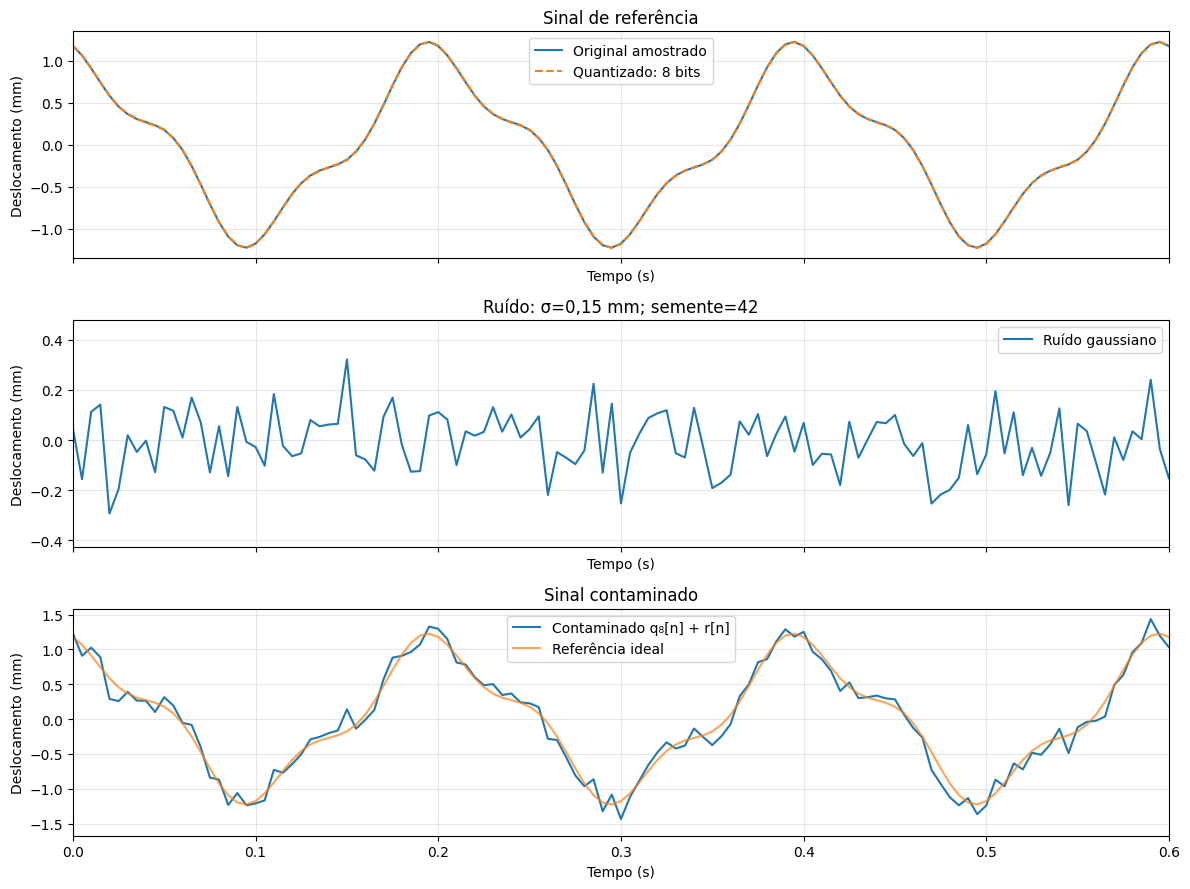

Média observada do ruído: -0.000778 mm
Desvio padrão observado: 0.142673 mm


In [5]:
q = quantizados[8]
r = rng.normal(0.0, sigma, size=n.size)
xr = q + r
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(tn, x, label="Original amostrado")
axes[0].plot(tn, q, linestyle="--", label="Quantizado: 8 bits")
axes[1].plot(tn, r, label="Ruído gaussiano")
axes[2].plot(tn, xr, label="Contaminado q₈[n] + r[n]")
axes[2].plot(tn, x, alpha=0.7, label="Referência ideal")
for ax, titulo in zip(axes, ["Sinal de referência", "Ruído: σ=0,15 mm; semente=42", "Sinal contaminado"]):
    configurar(ax, titulo)
    ax.set_xlim(0, 0.6)
    ax.legend()
plt.tight_layout()
plt.show()
print(f"Média observada do ruído: {np.mean(r):.6f} mm")
print(f"Desvio padrão observado: {np.std(r):.6f} mm")


**Interpretação:** a perturbação oscila em torno de zero e introduz variações irregulares sobre o sinal quantizado. Os valores observados da média e do desvio padrão diferem dos parâmetros teóricos porque há apenas 400 amostras. A forma periódica continua reconhecível, mas apresenta irregularidades que motivam a filtragem.

### Etapa 6 — Sistema LTI e convolução

Escolhemos a média móvel causal de $M=5$ amostras:

$$h[n]=\begin{cases}1/5,&0\leq n\leq4,\\0,&\text{caso contrário},\end{cases}\qquad y[n]=(x_r*h)[n]=\frac15\sum_{k=0}^{4}x_r[n-k].$$

A janela corresponde a $M/f_s=25$ ms; o atraso de grupo é $(M-1)/2=2$ amostras, ou 10 ms. Usamos convolução completa, com extensão por zeros fora do registro. A saída possui $400+5-1=404$ amostras. O sistema é linear porque a soma ponderada preserva superposição, e invariante no tempo porque seus coeficientes não dependem de $n$. É causal e estável, com $\sum_n|h[n]|=1$.

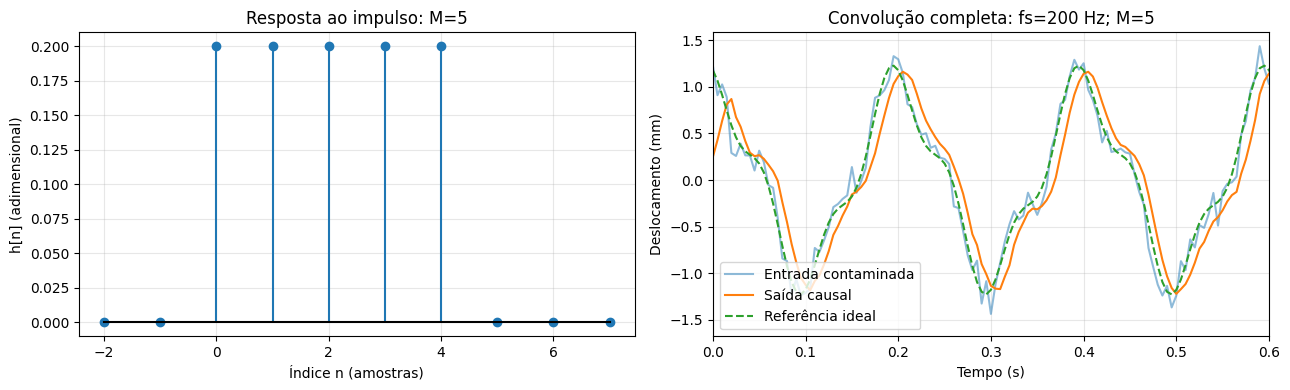

In [6]:
h = np.ones(M) / M
y = np.convolve(xr, h, mode="full")
y_ideal = np.convolve(x, h, mode="full")
y_quantizado = np.convolve(q, h, mode="full")
y_ruido = np.convolve(r, h, mode="full")
ny = np.arange(y.size)
ty = ny * Ts

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
nh = np.arange(-2, M + 3)
h_plot = np.where((nh >= 0) & (nh < M), 1 / M, 0)
axes[0].stem(nh, h_plot, basefmt="k-")
configurar(axes[0], "Resposta ao impulso: M=5", ylabel="h[n] (adimensional)", xlabel="Índice n (amostras)")
axes[1].plot(tn, xr, alpha=0.5, label="Entrada contaminada")
axes[1].plot(ty, y, label="Saída causal")
axes[1].plot(tn, x, linestyle="--", label="Referência ideal")
axes[1].set_xlim(0, 0.6)
configurar(axes[1], "Convolução completa: fs=200 Hz; M=5")
axes[1].legend()
plt.tight_layout()
plt.show()
assert np.allclose(y, y_quantizado + y_ruido)


**Interpretação:** o impulso gera cinco amostras de amplitude 0,2 na saída. A convolução suaviza a entrada e introduz atraso. No início e no final, a janela contém zeros da extensão do registro, produzindo transientes. A média móvel também atenua componentes úteis; suavização não significa preservação perfeita da vibração.

### Etapa 7 — Comparação e medidas

Para separar redução do ruído de distorção, filtramos também a referência sem ruído. Na região em que todas as cinco amostras existem ($4\leq n\leq399$), a parcela de ruído na saída é $y_r[n]=(r*h)[n]$. Para ruído independente, o desvio padrão teórico após a média é $\sigma/\sqrt M\approx0{,}0671$ mm.

A comparação com a referência compensa apenas o atraso conhecido de duas amostras e exclui as bordas. A saída efetiva continua sendo causal; a compensação é usada exclusivamente para avaliar os resultados.

,Medida,Valor (mm)
0,RMSE da entrada contaminada versus ideal,0.143093
1,RMSE da saída alinhada versus ideal,0.077124
2,RMSE da referência filtrada (distorção),0.040420
3,Desvio padrão do ruído na entrada,0.142673
4,Desvio padrão do ruído na saída (sem bordas),0.063830
5,Desvio padrão teórico do ruído na saída,0.067082


,Frequência (Hz),Ganho em amplitude,Atenuação (%)
0,5.0,0.9755,2.4502
1,15.0,0.7915,20.8483


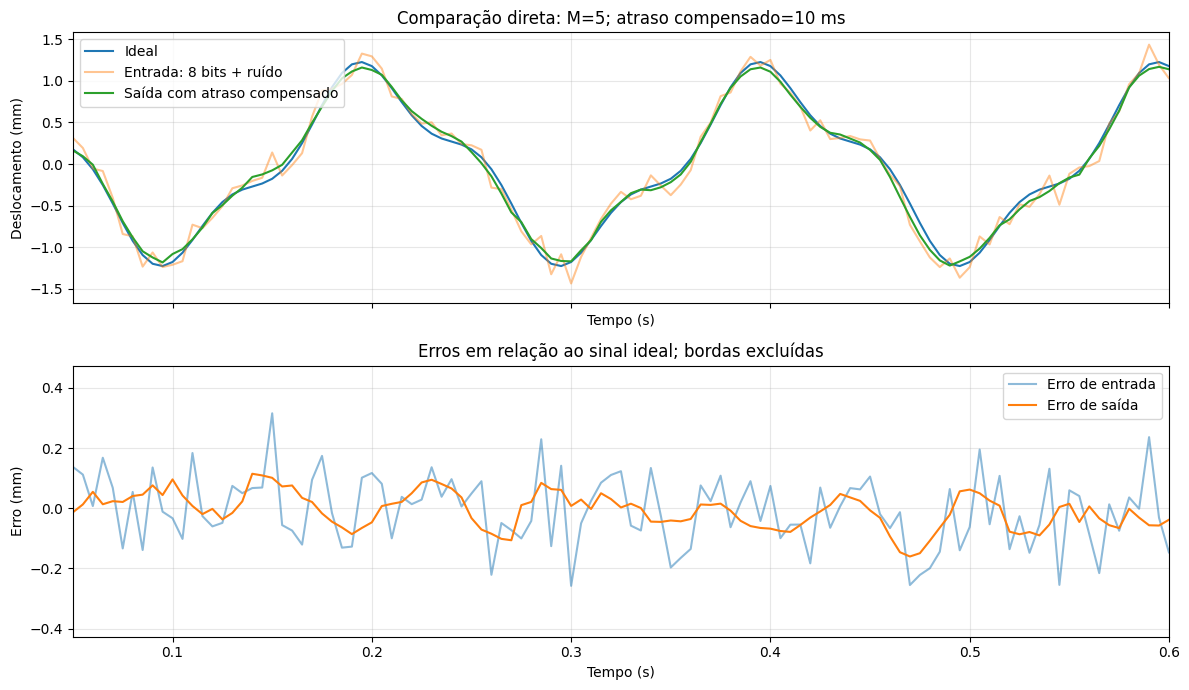

Verificações: comprimento da convolução, superposição e limites do erro de quantização corretos.


In [7]:
atraso = (M - 1) // 2
validos = np.arange(M - 1, len(x))
ref = x[validos - atraso]
entrada_alinhada = xr[validos - atraso]
saida_alinhada = y[validos]

metricas = pd.DataFrame([
    {"Medida": "RMSE da entrada contaminada versus ideal", "Valor (mm)": rmse(entrada_alinhada, ref)},
    {"Medida": "RMSE da saída alinhada versus ideal", "Valor (mm)": rmse(saida_alinhada, ref)},
    {"Medida": "RMSE da referência filtrada (distorção)", "Valor (mm)": rmse(y_ideal[validos], ref)},
    {"Medida": "Desvio padrão do ruído na entrada", "Valor (mm)": np.std(r)},
    {"Medida": "Desvio padrão do ruído na saída (sem bordas)", "Valor (mm)": np.std(y_ruido[validos])},
    {"Medida": "Desvio padrão teórico do ruído na saída", "Valor (mm)": sigma / np.sqrt(M)},
])
display(metricas.round(6))

ganhos = []
for freq in [f1, f2]:
    omega = 2 * np.pi * freq / fs
    ganho = abs(np.sum(h * np.exp(-1j * omega * np.arange(M))))
    ganhos.append({"Frequência (Hz)": freq, "Ganho em amplitude": ganho,
                   "Atenuação (%)": 100 * (1 - ganho)})
display(pd.DataFrame(ganhos).round(4))

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
tref = tn[validos - atraso]
axes[0].plot(tref, ref, label="Ideal")
axes[0].plot(tref, entrada_alinhada, alpha=0.45, label="Entrada: 8 bits + ruído")
axes[0].plot(tref, saida_alinhada, label="Saída com atraso compensado")
axes[1].plot(tref, entrada_alinhada - ref, alpha=0.5, label="Erro de entrada")
axes[1].plot(tref, saida_alinhada - ref, label="Erro de saída")
for ax in axes:
    ax.set_xlim(0.05, 0.6)
    ax.legend()
configurar(axes[0], "Comparação direta: M=5; atraso compensado=10 ms")
configurar(axes[1], "Erros em relação ao sinal ideal; bordas excluídas", ylabel="Erro (mm)")
plt.tight_layout()
plt.show()

assert len(y) == len(xr) + len(h) - 1
assert np.allclose(y, np.convolve(q + r, h))
for N, valores in quantizados.items():
    passo = 2 * limite / (2 ** N - 1)
    assert np.max(np.abs(valores - x)) <= passo / 2 + 1e-12
print("Verificações: comprimento da convolução, superposição e limites do erro de quantização corretos.")


**Interpretação:** as tabelas distinguem o erro total, a distorção introduzida pelo filtro e a redução da componente de ruído. O ganho do filtro é aproximadamente 0,9755 em 5 Hz e 0,7915 em 15 Hz: a componente principal perde cerca de 2,45% da amplitude, e a harmônica perde cerca de 20,85%. A janela de cinco amostras reduz o ruído, mas altera a harmônica de forma relevante. A comparação alinhada permite avaliar essas mudanças sem confundi-las com o atraso causal.